# Projeto Semantix — Análise de Risco de Crédito

## Contexto

O acesso ao crédito possui papel importante na vida financeira das pessoas, mas determinadas características do perfil do cliente e das operações de crédito podem estar associadas a um maior risco de inadimplência.

Este projeto busca explorar dados relacionados ao perfil financeiro, características do empréstimo e histórico de crédito dos clientes, procurando identificar padrões que possam contribuir para a compreensão desse risco.

## Problemática

Quais características financeiras, socioeconômicas e relacionadas ao crédito estão associadas à ocorrência de inadimplência?

A investigação será realizada por meio de análise exploratória dos dados e, posteriormente, pela aplicação e comparação de modelos estatísticos e de Machine Learning.

## Dataset

O projeto utiliza um conjunto de dados de risco de crédito contendo informações sobre idade, renda, propriedade, tempo de emprego, finalidade e características do empréstimo, taxa de juros, comprometimento da renda e histórico de crédito.

A variável `loan_status` será utilizada como indicador de ocorrência de inadimplência.

## Objetivo

Explorar os padrões presentes nos dados e avaliar quais características apresentam maior relação com a ocorrência de inadimplência, utilizando técnicas de análise de dados, estatística e Machine Learning.

# Bibliotecas - 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Paleta de cores do projeto

cores = {
    "verde_escuro": "#14532D",
    "verde_medio": "#2E7D32",
    "verde": "#4CAF50",
    "verde_claro": "#A5D6A7",
    "fundo": "#F1F8F3",
    "texto": "#1B2E22"
}

# Legenda - 

| Variável                     | Significado                                       |
| ---------------------------- | ------------------------------------------------- |
| `person_age`                 | Idade                                             |
| `person_income`              | Renda anual                                       |
| `person_home_ownership`      | Tipo de propriedade/moradia                       |
| `person_emp_length`          | Tempo de emprego                                  |
| `loan_intent`                | Finalidade do empréstimo                          |
| `loan_grade`                 | Grau/classificação do empréstimo                  |
| `loan_amnt`                  | Valor do empréstimo                               |
| `loan_int_rate`              | Taxa de juros                                     |
| `loan_status`                | Inadimplência: 0 = não, 1 = sim                   |
| `loan_percent_income`        | Percentual da renda comprometido com o empréstimo |
| `cb_person_default_on_file`  | Histórico de inadimplência                        |
| `cb_person_cred_hist_length` | Tempo de histórico de crédito                     |


# 1. Exploração de Variáveis 

In [3]:
# Carregando dataset
df = pd.read_csv('../data/credit_risk_dataset.csv', sep=',')
df.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
# Tipos das variáveis
df.dtypes

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

In [5]:
# Verificando valores nulos
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [6]:
# Estatísticas descritivas das variáveis numéricas
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [7]:
# Verificar a distribuição da categoria de propriedade da casa
df["person_home_ownership"].value_counts()  

person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

A maior parte dos registros corresponde a pessoas que alugam ou possuem imóvel financiado, enquanto a categoria OTHER apresenta participação muito pequena.

In [8]:
# Verificar a distribuição da finalidade do empréstimo
df["loan_intent"].value_counts()

loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

Educação e despesas médicas são as principais finalidades dos empréstimos na base, enquanto melhorias residenciais apresentam o menor volume de registros.

In [9]:
# Verificar a distribuição do grau dos empréstimos
df["loan_grade"].value_counts()

loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

A categoria A apresenta a maior frequência, enquanto G apresenta a menor. A variável representa uma classificação dos empréstimos, porém o significado específico de cada categoria não está descrito nas informações disponíveis do dataset.

In [10]:
# Verificar a distribuição de histórico de inadimplência
df["cb_person_default_on_file"].value_counts()

cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64

O histórico de inadimplência é predominantemente negativo (N), mas existe uma parcela relevante de clientes com registros anteriores (Y). Essa variável poderá ser importante posteriormente para investigar sua relação com a inadimplência atual.

In [11]:
# Verificar a distribuição do status de inadimplência
df["loan_status"].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

A variável-alvo apresenta uma distribuição desigual entre as classes, com predominância de clientes não inadimplentes. Essa diferença deverá ser considerada posteriormente na construção e avaliação dos modelos.

# 2. Exploração das variáveis numéricas

In [12]:
# Estatísticas descritivas da variável idade
df["person_age"].describe()

count    32581.000000
mean        27.734600
std          6.348078
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max        144.000000
Name: person_age, dtype: float64

In [13]:
# Quantidade de pessoas com mais de 100 anos
(df["person_age"] > 100).sum()

np.int64(5)

A idade dos clientes está concentrada em valores relativamente baixos, com mediana de 26 anos. Foram identificados 5 registros acima de 100 anos, incluindo o máximo de 144 anos, que deverão ser investigados e tratados posteriormente.

In [14]:
# Estatísticas descritivas da variável renda
df["person_income"].describe()

count    3.258100e+04
mean     6.607485e+04
std      6.198312e+04
min      4.000000e+03
25%      3.850000e+04
50%      5.500000e+04
75%      7.920000e+04
max      6.000000e+06
Name: person_income, dtype: float64

A renda anual apresenta forte dispersão, com a maior parte dos registros concentrada abaixo de US$ 79.200, enquanto poucos valores extremamente elevados elevam a média. Esses valores extremos deverão ser investigados posteriormente.

In [15]:
# Quantidade de rendas acima de 1 milhão
(df["person_income"] > 1_000_000).sum()

np.int64(9)

A renda anual apresenta forte assimetria à direita, com a maioria dos registros concentrada em valores relativamente menores e poucos casos com rendas extremamente elevadas. Foram identificados 9 registros acima de US$ 1 milhão, que deverão ser investigados e tratados posteriormente.

In [16]:
df ['person_emp_length'].describe()

count    31686.000000
mean         4.789686
std          4.142630
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max        123.000000
Name: person_emp_length, dtype: float64

O tempo de emprego está concentrado entre 2 e 7 anos, com mediana de 4 anos. Entretanto, há um valor extremo de 123 anos, além de 895 registros ausentes, que deverão ser investigados e tratados posteriormente.

In [17]:
# Quantidade de registros com mais de 50 anos de emprego
(df["person_emp_length"] > 50).sum()

np.int64(2)

O tempo de emprego apresenta concentração em valores baixos, com mediana de 4 anos. Existem 895 valores ausentes e apenas 2 registros acima de 50 anos, incluindo o máximo de 123 anos. Esses casos deverão ser tratados na etapa de preparação.

In [18]:
df ['loan_amnt'].describe()

count    32581.000000
mean      9589.371106
std       6322.086646
min        500.000000
25%       5000.000000
50%       8000.000000
75%      12200.000000
max      35000.000000
Name: loan_amnt, dtype: float64

O valor dos empréstimos está concentrado principalmente entre US$ 5.000 e US$ 12.200, com mediana de US$ 8.000. Os valores variam de US$ 500 a US$ 35.000 e não apresentam, inicialmente, valores evidentemente incompatíveis.

In [19]:
df['loan_int_rate'].describe()

count    29465.000000
mean        11.011695
std          3.240459
min          5.420000
25%          7.900000
50%         10.990000
75%         13.470000
max         23.220000
Name: loan_int_rate, dtype: float64

As taxas de juros variam de 5,42% a 23,22%, com concentração em torno de 11%. Não foram identificados valores evidentemente incompatíveis, mas existem 3.116 registros sem informação de taxa, que deverão ser tratados na etapa de preparação.

In [20]:
df ['loan_percent_income'].describe()

count    32581.000000
mean         0.170203
std          0.106782
min          0.000000
25%          0.090000
50%          0.150000
75%          0.230000
max          0.830000
Name: loan_percent_income, dtype: float64

O comprometimento da renda com o empréstimo apresenta mediana de 15% e média de 17%. Embora a maior parte dos registros esteja abaixo de 23%, existem casos que chegam a comprometer 83% da renda, indicando valores elevados que merecem investigação posterior.

In [21]:
df ['cb_person_cred_hist_length'].describe()

count    32581.000000
mean         5.804211
std          4.055001
min          2.000000
25%          3.000000
50%          4.000000
75%          8.000000
max         30.000000
Name: cb_person_cred_hist_length, dtype: float64

O histórico de crédito apresenta mediana de 4 anos e média de 5,8 anos, com a maior parte dos registros concentrada em períodos relativamente curtos. Os valores variam de 2 a 30 anos e não apresentam, inicialmente, anomalias evidentes.

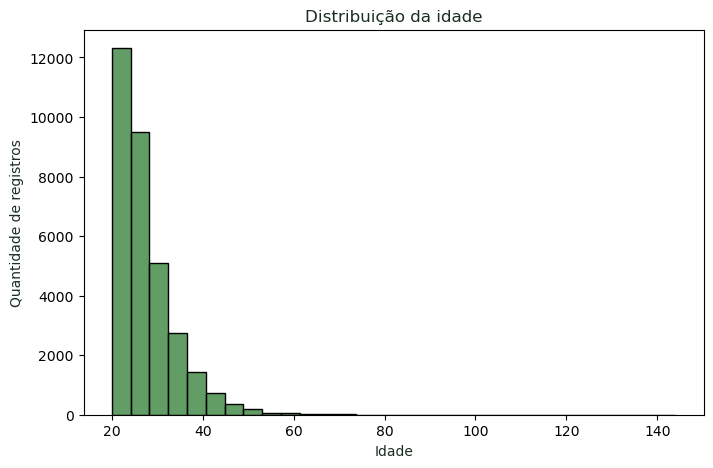

In [22]:
# Distribuição da idade
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="person_age",
    bins=30,
    color=cores["verde_medio"]
)

plt.title("Distribuição da idade", color=cores["texto"])
plt.xlabel("Idade", color=cores["texto"])
plt.ylabel("Quantidade de registros", color=cores["texto"])

plt.show()

A distribuição é fortemente concentrada entre 20 e aproximadamente 40 anos, com queda acentuada após essa faixa. A cauda se estende até 144 anos, mas os valores acima de 100 são praticamente imperceptíveis no gráfico devido à quantidade muito pequena de registros.
Isso mostra uma assimetria positiva (à direita) e reforça que os valores extremos de idade são muito diferentes do comportamento predominante da variável.

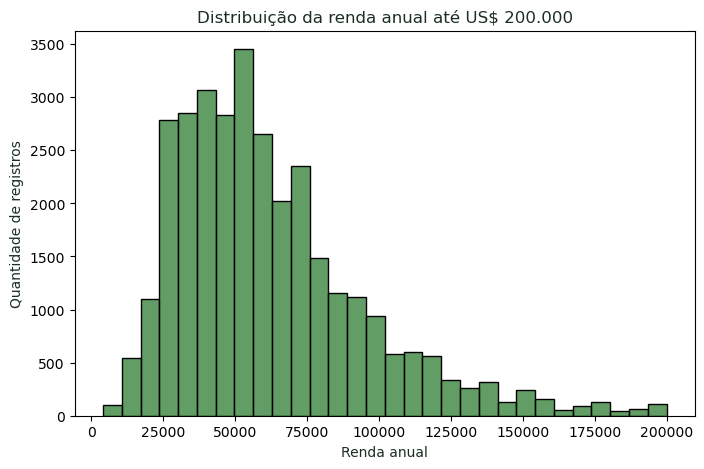

In [23]:
# Distribuição da renda até 200 mil
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df[df["person_income"] <= 200000],
    x="person_income",
    bins=30,
    color=cores["verde_medio"]
)

plt.title("Distribuição da renda anual até US$ 200.000", color=cores["texto"])
plt.xlabel("Renda anual", color=cores["texto"])
plt.ylabel("Quantidade de registros", color=cores["texto"])

plt.show()

A maior concentração de renda está entre aproximadamente US$ 25 mil e US$ 75 mil, com pico próximo de US$ 50–55 mil. A frequência diminui conforme a renda aumenta, caracterizando uma distribuição assimétrica à direita e evidenciando a presença de poucos valores muito elevados.

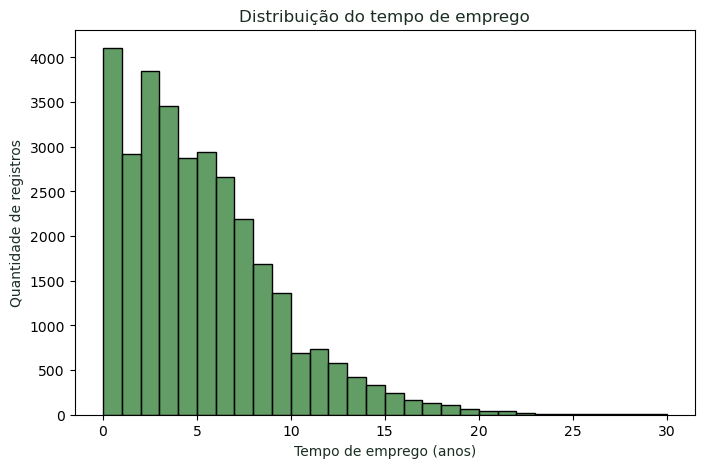

In [24]:
# Distribuição do tempo de emprego
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df[df["person_emp_length"] <= 30],
    x="person_emp_length",
    bins=30,
    color=cores["verde_medio"]
)

plt.title("Distribuição do tempo de emprego", color=cores["texto"])
plt.xlabel("Tempo de emprego (anos)", color=cores["texto"])
plt.ylabel("Quantidade de registros", color=cores["texto"])

plt.show()

O tempo de emprego está fortemente concentrado nos primeiros anos de atividade profissional, com redução progressiva da frequência conforme o tempo aumenta. A distribuição apresenta assimetria à direita, além dos poucos valores extremos identificados anteriormente.

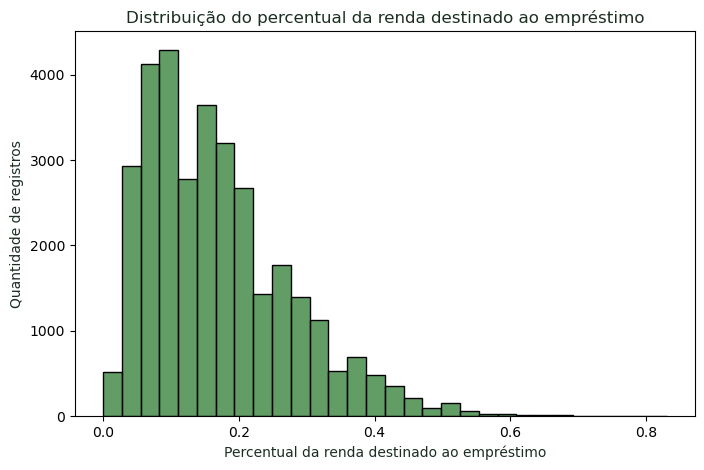

In [25]:
# Distribuição do tempo de emprego
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df[df["loan_percent_income"] <= 30],
    x="loan_percent_income",
    bins=30,
    color=cores["verde_medio"]
)

plt.title("Distribuição do percentual da renda destinado ao empréstimo", color=cores["texto"])
plt.xlabel("Percentual da renda destinado ao empréstimo", color=cores["texto"])
plt.ylabel("Quantidade de registros", color=cores["texto"])

plt.show()

O comprometimento da renda com o empréstimo está concentrado principalmente entre 5% e 20%, enquanto níveis mais elevados são progressivamente menos frequentes. Embora existam registros que chegam a 83%, eles representam uma parcela muito pequena da amostra.

# Conclusão da Etapa de Exploração -

A análise exploratória revelou que o conjunto de dados apresenta características relevantes para a investigação do risco de inadimplência. A maior parte dos registros corresponde a clientes relativamente jovens, com renda e tempo de emprego concentrados em faixas mais baixas, enquanto variáveis como renda anual e tempo de emprego apresentam assimetria e valores extremos pontuais.

O comprometimento da renda com o empréstimo apresenta maior concentração em níveis relativamente baixos, porém existem registros com comprometimento significativamente elevado. Também foi identificada uma distribuição desigual da variável loan_status, com predominância de clientes não inadimplentes e uma parcela menor de registros classificados como inadimplentes.

Além disso, foram identificados valores ausentes em person_emp_length e loan_int_rate, bem como valores extremos em algumas variáveis numéricas. Esses aspectos não serão corrigidos nesta etapa, mas deverão ser considerados na preparação dos dados para evitar que comprometam as análises e os modelos posteriores.

Dessa forma, a exploração fornece uma visão inicial do perfil dos dados e dos principais pontos que precisam ser tratados antes da modelagem, permitindo avançar para a etapa de preparação de forma fundamentada.